# 01. Data, features, multicollinearity and transformations

This notebook prepares everything that both modelling notebooks (`02_classification.ipynb`, `03_regression.ipynb`) share. It loads and cleans the Olist data, builds the 41 candidate predictors, defines the late-delivery label and the days-from-promise target, reduces the predictors to a frozen set of 24 raw features by a multicollinearity screen, decides the transformations the plain linear models will use, and draws the Train / CV / Validation / Test (June) / Monitoring timeline. Every decision here uses Train rows only.

**Contents**
1. Data load and cleaning summary
2. Feature table: how the 41 candidates are built
3. Labels and targets, rows per split, buffer audit and waiting-period audit
4. Multicollinearity: 41 candidates to 24 raw features
5. Transformations for the linear models (log1p, cyclic calendar, merged Mixed route, VIF of the final design)
6. Timeline and CV fold diagrams

Figures are saved to `results/simple_to_complex/figures/01_*.png` and tables to `results/simple_to_complex/data/`. The multicollinearity audit writes to its canonical folder, `results/feature_selection/`.

## Setup

Imports, output folders and the shared constants. `RUN_DATE`, the 45-day buffer and the 365-day window come from `src`, so every notebook uses the same values.

In [1]:
from pathlib import Path

import pandas as pd

from src import LOOKBACK, PXD
from src import data_audits as audits
from src import report_figures as figs
from src.data import load_olist_data
from src.datasets import build_task_data
from src.feature_selection import (audit, candidate_feature_status, candidate_feature_table,
                                   encoded_block_summary, exact_overlap_table, imputed_numeric,
                                   stage_summary, training_rows)
from src.features import SELECTED_CAT_COLS, SELECTED_NUM_COLS, add_extra_features, build_feature_table
from src.preprocessing import make_preprocessor
from src.validation_timelines import plot_validation_timelines, task_timeline

FIGURE_DIR = Path('results/simple_to_complex/figures')
DATA_DIR = Path('results/simple_to_complex/data')
MULTICOLLINEARITY_DIR = Path('results/feature_selection')
for folder in (FIGURE_DIR, DATA_DIR):
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_colwidth', 120)

# 1. Data load and cleaning summary

Nine Olist tables are loaded; product categories are translated to English with `Unknown` for missing values. `build_feature_table` then aggregates items, products, sellers, customers, payments and geolocation to **one row per approved order** (orders from January 2017 on), and `add_extra_features` appends further approval-time predictors. The tables below show the raw sizes and every row dropped on the way to the order-level table. Missing values are not removed here: each model pipeline imputes them with medians fitted on its own training rows.

In [2]:
olist = load_olist_data(verbose=False)
final_df = add_extra_features(build_feature_table(olist), olist)
orders = olist['orders']
raw_tables = audits.raw_table_summary(olist)
raw_tables.to_csv(DATA_DIR / '01_raw_tables.csv', index=False)
raw_tables

,table,rows,columns,missing_cells,duplicate_rows
0,orders,99441,8,4908,0
1,order_items,112650,7,0,0
2,customers,99441,5,0,0
3,products,32951,9,1838,0
4,sellers,3095,4,0,0
5,payments,103886,5,0,0
6,reviews,99224,7,145903,0
7,geolocation,1000163,5,0,261831
8,category_translation,71,2,0,0


In [3]:
cleaning = audits.cleaning_steps(olist, final_df)
cleaning.to_csv(DATA_DIR / '01_cleaning_steps.csv', index=False)
cleaning

,step,orders
0,Orders in the raw orders table,99441
1,Without an approval timestamp (dropped: no prediction point),160
2,Approved orders,99281
3,Approved before January 2017 (dropped: sparse early months),322
4,Order-level feature table (one row per order),98959
5,of which delivered before approval (kept; label rules mark them invalid),38
6,of which canceled or unavailable (dropped from regression only),1067


Missing values in the modelling features, over all approved orders in the feature table. Distances are missing when a zip prefix has no geolocation record. Product and item fields are missing for orders without item rows. Nothing else is missing.

In [4]:
missing = audits.feature_missingness(final_df, SELECTED_NUM_COLS + SELECTED_CAT_COLS)
missing.to_csv(DATA_DIR / '01_feature_missingness.csv', index_label='feature')
missing

,missing,share_pct
order_product_photos_mean,2005,2.03
seller_dist_km_mean,1108,1.12
order_product_volume_cm3_sum,635,0.64
order_item_count,619,0.63
order_seller_count,619,0.63
order_frieght_value_sum,619,0.63
order_product_weight_g_sum,619,0.63
order_product_category_count,619,0.63
seller_state_count,619,0.63
freight_to_price_ratio,619,0.63


# 2. Feature table: how the 41 candidates are built

The prediction point is the order's approval, so every predictor must be known at approval. Delivery dates, delivery durations and order status define the outcomes and are never predictors (`LEAKAGE_COLS` in `src/features.py`). The table mirrors the "Feature engineering: 41 candidate predictors" table in `MULTICOLLINEARITY_NOTES.md`; `candidate_feature_table` checks that the groups cover exactly the feature lists in `src/features.py`.

| Group | Built from | Candidate features |
|---|---|---|
| Approval calendar | `order_approved_at` | day of week, day of month, month, ISO week of year (4) |
| Basket contents | order items + products | item count, distinct sellers, distinct product categories, summed price, freight, revenue (price + freight) and weight (7) |
| Seller location | sellers + geolocation | haversine seller-to-customer distance (from median zip-prefix coordinates) as max, min, median and mean over the order's sellers; distinct seller zip prefixes, cities and states (7) |
| Payment | payments | total payment value; value and count for each payment type: boleto, credit card, debit card, voucher, not defined (11) |
| Promise and approval | orders | promised lead days (estimated delivery date shown at checkout minus approval date); approval lag in hours (2) |
| Product catalogue | products | summed volume (length x height x width), mean number of photos (2) |
| Price structure | items, payments | freight-to-price ratio; maximum instalments chosen (2) |
| Seasonality and load | approval date, all orders | weekend flag, Black Friday period flag (20 to 30 Nov 2017), December flag; orders approved platform-wide in the 7 completed days before approval (4) |
| Categorical | customers, items + sellers | customer state; route type: all interstate, all same-state or mixed (2) |

That is 29 base numeric + 10 extra numeric + 2 categorical = **41 candidates**. A third categorical, `payment_combination` (the sorted set of payment types used, joined with `+`), is derived to replace the per-method payment columns after the screen in section 4.

In [5]:
feature_groups = candidate_feature_table()
feature_groups.to_csv(DATA_DIR / '01_candidate_feature_groups.csv', index=False)
print(f'{feature_groups["count"].sum()} candidate predictors')
feature_groups

41 candidate predictors


,group,built_from,count,columns
0,Approval calendar,order_approved_at,4,"order_approved_day_of_week, order_approved_day_of_month, order_approved_month, order_approved_week_of_year"
1,Basket contents,order items + products,7,"order_item_count, order_seller_count, order_product_category_count, order_pdt_price_sum, order_frieght_value_sum, or..."
2,Seller location,sellers + geolocation,7,"seller_dist_km_max, seller_dist_km_min, seller_dist_km_median, seller_dist_km_mean, seller_zip_code_prefix_count, se..."
3,Payment,payments,11,"payment_value_sum, payment_type_value_boleto, payment_type_value_credit_card, payment_type_value_debit_card, payment..."
4,Promise and approval,orders,2,"promised_lead_days, approval_lag_hours"
5,Product catalogue,products,2,"order_product_volume_cm3_sum, order_product_photos_mean"
6,Price structure,"items, payments",2,"freight_to_price_ratio, payment_installments_max"
7,Seasonality and load,"approval date, all orders",4,"is_weekend_approval, is_black_friday_period, is_december_peak, orders_approved_prev_7d"
8,Categorical,"customers, items + sellers",2,"customer_state, route_type"


In [6]:
feature_status = candidate_feature_status()
feature_status.to_csv(DATA_DIR / '01_candidate_feature_status.csv', index=False)
feature_status.groupby('group', sort=False)['kept'].agg(candidates='size', kept_in_final='sum').astype(int)

,candidates,kept_in_final
group,,
Approval calendar,4,3
Basket contents,7,5
Seller location,7,2
Payment,11,1
Promise and approval,2,2
Product catalogue,2,2
Price structure,2,2
Seasonality and load,4,4
Categorical,2,2


# 3. Labels and targets

Both tasks are defined **as of the run date, 2 June 2018** (inference date 1 June), using only calendar dates before the run date. `src.datasets.build_task_data` is the single source of Train, Validation, history and CV folds, so these row counts are identical in notebooks 02 and 03.

**Classification label** (`labels_as_of`)

| Outcome as of the run date | Label |
|---|---|
| Delivered on or before the promised delivery day | **0, on time** |
| Delivered after the promised delivery day | **1, late** |
| Still undelivered and the promised delivery day has fully passed | **1, late** |
| Still undelivered and the promised delivery day has not fully passed | unknown, excluded from training |

Comparisons use calendar dates. A delivery dated on or after the run date is not yet observed. Orders with missing or inconsistent dates (for example delivery before approval) have an unknown label. For example, an order estimated for 1 June that is still undelivered at the 2 June run is known to be late; one estimated for 2 June still has the rest of that day to arrive on time.

**Regression target** (`regression_targets_as_of`): days from the promised date, positive when late.

$$y = \min(\text{lead days},\ W) - \text{promised lead days}, \qquad W = 45$$

`lead days` is delivery date minus approval date and `promised lead days` is the estimated date minus approval date, which is known at checkout. For an order delivered within *W* days this is simply delivery date minus estimated date. A slow order still undelivered after *W* days is right-censored; recording it at *W* keeps the worst deliveries in the data instead of silently dropping them. Canceled and unavailable orders never get a delivery outcome and are excluded from regression only.

**Splits** (plan section 2). **Train** is the buffered development-training rows, approved before the 45-day gap that precedes Validation and with outcomes known when Validation starts. **CV** is five expanding chronological folds inside Train. **Validation** is the newest 30 approval days (19 March to 17 April 2018), used for diagnostics only. **Test (June)** and **Monitoring (July, August)** come later and are scored in notebooks 02 and 03.

## Rows per split

`build_task_data` checks the expected Train sizes (classification 45,972; regression 45,371). The funnel shows where orders drop out between the 365-day window and Train.

In [7]:
task_data = {task: build_task_data(task, final_df) for task in ('classification', 'regression')}
funnel = pd.concat([audits.population_funnel(td, final_df) for td in task_data.values()])
step_order = funnel.query('task == "regression"')['step'].tolist()
funnel.pivot(index='step', columns='task', values='orders').reindex(step_order).astype('Int64')

task,classification,regression
step,,
Approved orders in the 365-day window,63605,63605
After dropping canceled and unavailable orders,<NA>,62852
Outcome known on the run date (history),63592,62841
Validation (newest 30 approval days),6870,6847
Excluded: 45-day gap and outcomes not yet known,10750,10623
Train,45972,45371


In [8]:
split_summary = pd.concat([audits.target_summary(td).assign(task=task) for task, td in task_data.items()])
split_summary.to_csv(DATA_DIR / '01_split_summary.csv', index=False)
funnel.to_csv(DATA_DIR / '01_population_funnel.csv', index=False)
for task, table in split_summary.groupby('task', sort=False):
    display(table.drop(columns='task').dropna(axis=1, how='all').set_index('split').rename_axis(task))

,orders,late_orders,late_rate_pct
classification,,,
Train,45972,"4,061.00",8.83
Validation,6870,713.00,10.38
History,63592,"6,963.00",10.95


,orders,mean_days,median_days,sd_days,late_share_pct
regression,,,,,
Train,45371,-11.44,-13.00,9.16,7.55
Validation,6847,-9.78,-11.00,9.46,10.02
History,62841,-10.51,-12.00,9.66,9.80


## Classification: buffer audit

The buffer is the gap between the newest training approval and the inference date. A longer buffer lets more outcomes arrive, so more labels are known, but the training data gets older. The audit checks, for several historical run dates, how many orders in the 365-day window have a known label for buffers of 15 to 60 days. The target is at least 99% known in every run and for the newest 7 days of the window, which is the hardest part to complete.

In [9]:
buffer_review, buffer_summary = audits.buffer_label_audit(
    orders, final_df['order_id'], run_dates=['2018-04-01', '2018-05-01', '2018-06-01'],
    buffer_days=[15, 30, 45, 60], window_days=PXD)
buffer_review.to_csv(DATA_DIR / '01_buffer_audit.csv', index=False)
buffer_summary

,buffer_days,worst_completeness_pct,meets_target_everywhere
0,15,62.09,False
1,30,98.40,False
2,45,99.87,True
3,60,99.95,True


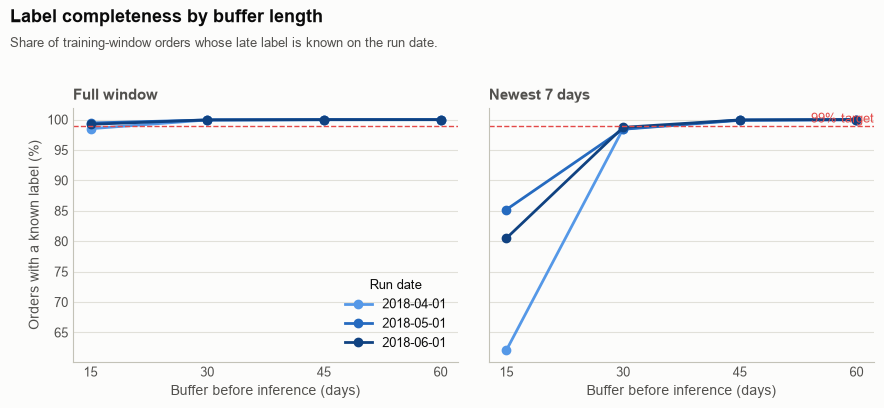

In [10]:
figs.plot_buffer_audit(buffer_review, save_path=FIGURE_DIR / '01_label_buffer_audit.png')

The smallest buffer that reaches 99% in every run and scope is the 45 days used throughout (`LOOKBACK`). This is historical evidence, not a guarantee for future runs. Label availability for the actual 2 June training window:

In [11]:
label_availability = audits.label_availability(task_data['classification'], final_df)
label_availability.to_csv(DATA_DIR / '01_label_availability.csv', index_label='label_status')
label_availability

,orders,share_pct
label_status,,
on_time_delivered,56629,89.03
late_delivered,5015,7.88
late_undelivered,1948,3.06
invalid_or_missing_dates,11,0.02
unresolved,2,0.00


## Regression: waiting-period audit

The waiting period *W* caps the lead time. A shorter cap loses detail in the long-delay tail; a longer cap needs a longer buffer. For each run date and candidate *W*, the audit counts the training orders that hit the cap, and those capped before their promised date (recorded as early although the true outcome is unknown). `LOOKBACK = 45` is the longest cap whose targets are fully known for every training order.

In [12]:
lead_summary = audits.delivered_lead_summary(final_df)
lead_summary.to_csv(DATA_DIR / '01_delivered_lead_summary.csv', index_label='measure')
lead_summary

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
lead_days,"96,190.00",11.97,9.51,-7.00,2.00,6.00,10.00,15.00,29.00,45.00,208.00
days_from_promise,"96,190.00",-11.81,10.09,-147.00,-26.00,-17.00,-12.00,-7.00,3.00,18.00,188.00


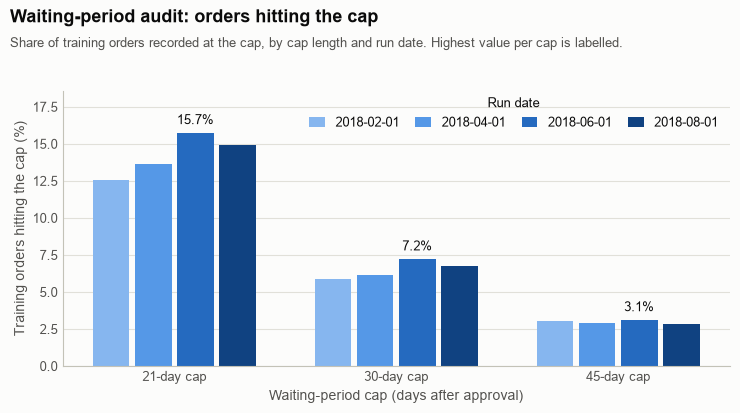

,run_date,waiting_period,orders,known_pct,capped_pct,capped_before_promise_pct,unresolved_pct
0,2018-02-01,21,42427,99.98,12.54,10.71,0.00
1,2018-02-01,30,42427,99.98,5.91,2.18,0.00
2,2018-02-01,45,42427,99.98,3.04,0.14,0.00
3,2018-04-01,21,52671,99.98,13.65,11.98,0.00
4,2018-04-01,30,52671,99.98,6.17,2.41,0.00
5,2018-04-01,45,52671,99.98,2.92,0.12,0.00
6,2018-06-01,21,62581,99.98,15.74,13.09,0.00
7,2018-06-01,30,62581,99.98,7.22,2.38,0.00
8,2018-06-01,45,62581,99.98,3.11,0.11,0.00
9,2018-08-01,21,69405,99.98,14.94,12.36,0.00


In [13]:
waiting_audit = audits.waiting_period_audit(
    final_df, run_dates=['2018-02-01', '2018-04-01', '2018-06-01', '2018-08-01'],
    waiting_periods=[21, 30, 45], lookback=LOOKBACK, window_days=PXD)
waiting_audit.to_csv(DATA_DIR / '01_waiting_period_audit.csv', index=False)
figs.plot_waiting_period_audit(waiting_audit, save_path=FIGURE_DIR / '01_waiting_period_audit.png')
waiting_audit

**Reading the audit.** At *W* = 45 only about 1% of delivered orders exceed the cap; counting shipped-but-never-delivered orders, a few percent of training orders are capped, and every valid target is known. At *W* = 30 and *W* = 21 the capped share grows several-fold, and many orders are recorded as early before their promised date. The decision is therefore `WAITING_PERIOD = LOOKBACK = 45`, so one buffer serves both tasks.

# 4. Multicollinearity: 41 candidates to 24 raw features

Strongly correlated predictors make linear and logistic coefficients unstable and impossible to read as the effect of one predictor with the others held fixed, and an exact identity makes the design singular. Trees predict well regardless, but split importance is shared arbitrarily between near-duplicates. One feature set is therefore chosen once, before modelling, for both tasks, every fold, every month and both model families. It uses only the Train rows of both tasks (45,972 classification and 45,371 regression orders) and no outcome from Validation, June, July or August is used to choose a predictor.

The rules, in order: remove constants; remove columns with a prespecified domain representative (exact identities and near-duplicates); then repeatedly drop the numeric column with the greatest VIF in either task until all are at most 5 (`payment_value_sum` is exempt). The reasoning and limitations are documented in `MULTICOLLINEARITY_NOTES.md`. Here the audit is re-run from the Train rows of this notebook, and its output must equal `SELECTED_NUM_COLS`.

In [14]:
audit_rows = training_rows(final_df)
for task, td in task_data.items():
    assert set(audit_rows[task]['order_id']) == td.train_ids, f'{task}: audit rows differ from Train'
exact_overlaps = exact_overlap_table(audit_rows)
MULTICOLLINEARITY_DIR.mkdir(parents=True, exist_ok=True)
exact_overlaps.to_csv(MULTICOLLINEARITY_DIR / 'exact_overlaps.csv', index=False)
exact_overlaps

,task,comparison,rows,equal_fraction_1e_8,max_absolute_difference
0,classification,revenue_minus_price_and_freight,45560,1.00,0.00
1,classification,payment_total_minus_type_values,45972,1.00,0.00
2,classification,distance_max_minus_mean,45308,0.99,"1,127.48"
3,classification,distance_mean_minus_min,45308,0.99,"1,127.48"
4,regression,revenue_minus_price_and_freight,45371,1.00,0.00
5,regression,payment_total_minus_type_values,45371,1.00,0.00
6,regression,distance_max_minus_mean,45121,0.99,"1,127.48"
7,regression,distance_mean_minus_min,45121,0.99,"1,127.48"


The audit population matches Train exactly in both tasks. The exact-identity checks above show why revenue (price plus freight), the per-method payment columns (which sum to the payment total) and the seller-distance summaries (equal to the mean for about 99% of orders) are redundant.

In [15]:
selected_numeric = audit({task: imputed_numeric(rows) for task, rows in audit_rows.items()},
                         audit_rows, output=MULTICOLLINEARITY_DIR)
assert selected_numeric == SELECTED_NUM_COLS, 'Audit result differs from SELECTED_NUM_COLS'
removal_trace = pd.read_csv(MULTICOLLINEARITY_DIR / 'removal_trace.csv')
vif_before = pd.read_csv(MULTICOLLINEARITY_DIR / 'numeric_vif_before.csv', index_col='feature')
stage_summary(removal_trace, start_count=len(vif_before))

,stage,removed,removed_columns,numeric_remaining
0,start,0,,39
1,constant,2,"payment_type_value_not_defined, payment_type_count_not_defined",37
2,domain representative,13,"order_approved_week_of_year, order_revenue_sum, seller_dist_km_max, seller_dist_km_min, seller_dist_km_median, payme...",24
3,iterative VIF,3,"order_pdt_price_sum, seller_zip_code_prefix_count, seller_city_count",21


In [16]:
removal_trace

,step,stage,removed,reason,classification_vif_at_removal,regression_vif_at_removal
0,1,constant,payment_type_value_not_defined,constant in at least one development-training task,inf,inf
1,2,constant,payment_type_count_not_defined,constant in at least one development-training task,inf,inf
2,3,domain representative,order_approved_week_of_year,month and day represent calendar timing,"33,163.47","33,258.62"
3,4,domain representative,order_revenue_sum,exact sum of price and freight; retain component candidates for VIF stage,"1,079,750.70",inf
4,5,domain representative,seller_dist_km_max,mean represents seller distance,"5,622,816.24","5,664,307.82"
5,6,domain representative,seller_dist_km_min,mean represents seller distance,"2,387.60","2,377.39"
6,7,domain representative,seller_dist_km_median,mean represents seller distance,"109,360.43","109,111.58"
7,8,domain representative,payment_type_value_boleto,payment total and categorical payment combination represent payment,inf,inf
8,9,domain representative,payment_type_value_credit_card,payment total and categorical payment combination represent payment,5.79,5.75
9,10,domain representative,payment_type_value_debit_card,payment total and categorical payment combination represent payment,2.73,2.74


Numeric VIF before and after the screen (per task). Before, several VIFs are infinite (payment columns and, in regression, price, freight and revenue) and the distance summaries exceed five million. After, the largest numeric VIF is below 4 in both tasks.

In [17]:
vif_after = pd.read_csv(MULTICOLLINEARITY_DIR / 'numeric_vif_after.csv', index_col='feature')
vif_before.sort_values('classification', ascending=False).head(15)

,classification,regression
feature,,
payment_type_value_boleto,inf,inf
payment_type_value_debit_card,inf,inf
payment_value_sum,inf,inf
payment_type_value_not_defined,inf,inf
payment_type_value_voucher,inf,inf
payment_type_count_not_defined,inf,inf
payment_type_value_credit_card,inf,inf
seller_dist_km_mean,"51,762,665.27","51,778,772.81"
seller_dist_km_median,"6,007,467.60","6,009,297.82"


In [18]:
vif_after.sort_values('classification', ascending=False)

,classification,regression
feature,,
order_frieght_value_sum,3.76,3.79
order_product_weight_g_sum,3.39,3.40
order_product_volume_cm3_sum,3.35,3.37
order_approved_day_of_week,2.38,2.38
is_weekend_approval,2.36,2.36
is_black_friday_period,2.33,2.33
order_seller_count,2.29,2.29
is_december_peak,2.16,2.17
orders_approved_prev_7d,1.98,1.98


**Encoding (24 raw features to 53 columns).** Every row has exactly one level of each categorical, so a full set of dummies sums to the intercept: with an intercept, full one-hot coding is perfectly collinear (the dummy-variable trap). `make_preprocessor(..., reference_categories=True)` drops one reference level per categorical (`SP`, `1. All interstate`, single-method `credit_card`), so each dummy coefficient is a contrast with that reference. The 21 numeric plus 26 + 2 + 4 dummy columns give 53 encoded columns, full rank after centring in both tasks.

In [19]:
reference_coded = make_preprocessor(SELECTED_NUM_COLS, SELECTED_CAT_COLS, reference_categories=True)
reference_coded.fit(task_data['classification'].X_train)
encoded_block_summary(reference_coded)

,block,raw_columns,levels_seen,reference_dropped,encoded_columns
0,numeric,21,<NA>,,21
1,customer_state,1,27,SP,26
2,route_type,1,3,1. All interstate,2
3,payment_combination,1,5,credit_card,4
4,total,24,<NA>,,53


In [20]:
pd.read_csv(MULTICOLLINEARITY_DIR / 'encoded_design_rank.csv')

,task,rows,encoded_columns,centered_rank,full_rank_with_intercept,max_encoded_vif
0,classification,45972,53,53,True,6.04
1,regression,45371,53,53,True,6.22


The largest encoded VIF is `seller_dist_km_mean` (about 6), because distance overlaps the route dummies. It is the single documented exception to VIF at most 5: distance measures how far the goods travel and route measures whether the shipment crosses a state border. The weekend, Black Friday and December flags are deterministic but nonlinear functions of the calendar columns, which VIF cannot see; they are kept deliberately as step effects for the linear models.

# 5. Transformations for the linear models

Trees are invariant to monotone transforms, so the transformations below apply to the **linear and logistic models only**; the Random Forest uses the 24 raw features unchanged. Everything is decided on Train and then fitted inside the modelling pipeline on the rows it is given. The choices that depend on model scores (whether each transform group improves CV, and a possible squared term) are made in notebooks 02 and 03, because they need the fitted models.

## 5.1 Skewness and log1p

A heavily right-skewed predictor lets a few extreme orders dominate a linear fit. For the eight amount, ratio, distance and lag variables named in the plan, `log1p` is applied when the raw |skew| on Train exceeds 1. The other skewed columns are discrete counts, binary flags or bounded catalogue attributes, which are left as they are. The table lists every numeric feature for both tasks; `log1p_applied` marks the decision.

In [21]:
skewness = pd.concat([audits.skewness_report(td.train_df, td.num_cols).assign(task=task)
                      for task, td in task_data.items()], ignore_index=True)
skewness.to_csv(DATA_DIR / '01_skewness.csv', index=False)
skew_candidates = skewness[skewness['candidate']].pivot(index='feature', columns='task',
                                                        values=['skew_raw', 'skew_log1p', 'log1p_applied'])
skew_candidates.reindex(audits.LOG1P_CANDIDATES)

skew_raw                skew_log1p  \
task                         classification regression classification   
feature                                                                 
payment_value_sum                     11.16      11.35           0.56   
order_frieght_value_sum                8.99       9.01           1.19   
order_product_weight_g_sum             6.70       6.70           0.38   
order_product_volume_cm3_sum           8.22       8.22          -0.04   
approval_lag_hours                     4.61       4.02           0.97   
seller_dist_km_mean                    1.69       1.68          -1.10   
freight_to_price_ratio                 5.01       3.74           1.93   
orders_approved_prev_7d                1.73       1.73           0.68   

                                         log1p_applied             
task                         regression classification regression  
feature                                                            
payment_value_sum                  0.56           True       True  
order_frieght_value_sum            1.19           True       True  
order_product_weight_g_sum         0.39           True       True  
order_product_volume_cm3_sum      -0.04           True       True  
approval_lag_hours                 0.97           True       True  
seller_dist_km_mean               -1.10           True       True  
freight_to_price_ratio             1.90           True       True  
orders_approved_prev_7d            0.68           True       True

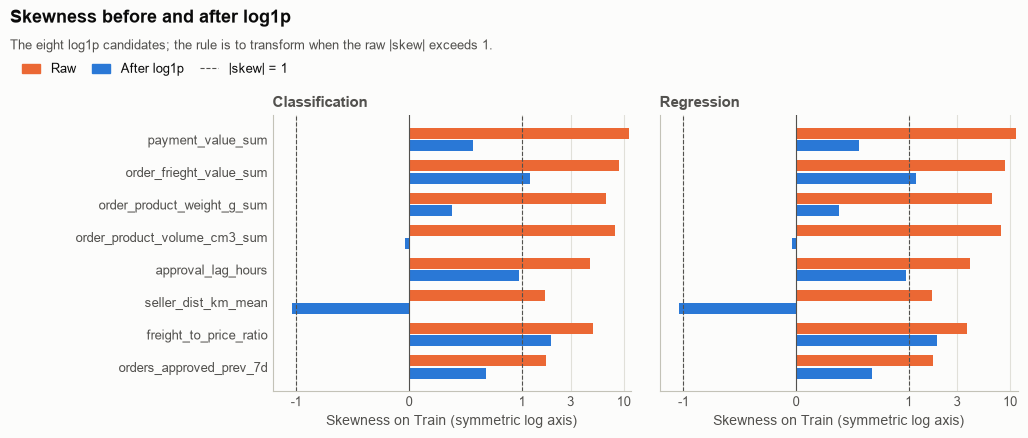

['order_frieght_value_sum',
 'order_product_weight_g_sum',
 'seller_dist_km_mean',
 'payment_value_sum',
 'approval_lag_hours',
 'order_product_volume_cm3_sum',
 'freight_to_price_ratio',
 'orders_approved_prev_7d']

In [22]:
log_columns = {task: skewness[(skewness['task'] == task) & skewness['log1p_applied']]['feature'].tolist()
               for task in task_data}
assert log_columns['classification'] == log_columns['regression'], 'Tasks disagree on log1p columns'
LOG_COLS = log_columns['classification']
pd.DataFrame({'log1p_columns': LOG_COLS}).to_csv(DATA_DIR / '01_log1p_columns.csv', index=False)
figs.plot_skewness({task: skewness[(skewness['task'] == task) & skewness['candidate']]
                    .set_index('feature').loc[audits.LOG1P_CANDIDATES].reset_index()
                    for task in task_data}, save_path=FIGURE_DIR / '01_skewness_before_after.png')
LOG_COLS

Both tasks select the same eight columns. `log1p` brings the skew of payment value, weight, volume, approval lag and platform load below 1 in absolute value. Freight, the freight-to-price ratio and distance improve but stay above 1 (distance slightly over-corrects to -1.1), so the CV comparison in notebooks 02 and 03 decides whether the log group is kept.

## 5.2 Cyclic calendar

Month (1 to 12) and day of week (1 to 7) are circular: December is next to January and Sunday next to Monday, but as plain numbers they are 11 and 6 apart. For the linear models each is replaced by a sine and cosine pair, `sin(2 pi x / period)` and `cos(2 pi x / period)`, which places the values on a circle. A set of month dummies is not used because they would be exactly collinear with the December flag and, together, with the other calendar flags. `order_approved_day_of_month` stays numeric, and the weekend, Black Friday and December flags are kept.

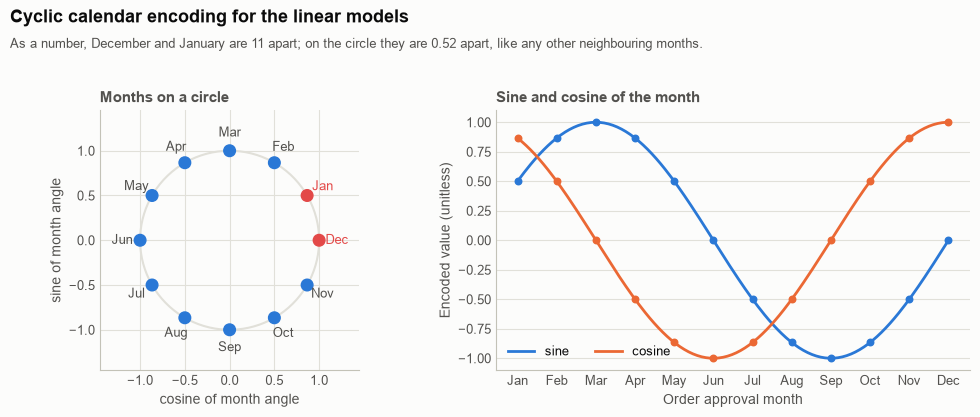

In [23]:
figs.plot_cyclic_calendar(save_path=FIGURE_DIR / '01_cyclic_calendar.png')

## 5.3 Merging the Mixed route for linear models

`route_type` has three levels. In Train, the **118 Mixed orders** (sellers in the customer's state and in other states) have **zero late orders**, and so do the **227 orders with two or more seller states** (`seller_state_count >= 2`). A plain, unpenalised logistic regression cannot estimate a coefficient for a level with no events: the maximum-likelihood estimate runs to minus infinity, which shows up as an enormous coefficient and standard error (quasi-separation). The regression target has no such problem, but the group is tiny there too.

For all linear models in both tasks the preprocessor folds `3. Mixed` into `1. All interstate` (`merge_mixed_route=True`). That is sensible because every Mixed order has at least one interstate leg. `seller_state_count` is kept as a feature; where its logistic coefficient is not identified, notebook 02 flags it in the coefficient table instead of hiding it. The Random Forest keeps the raw three levels.

In [24]:
route_tables = {task: audits.route_audit(td.train_df, task) for task, td in task_data.items()}
for task, table in route_tables.items():
    table.assign(task=task).to_csv(DATA_DIR / f'01_route_audit_{task}.csv', index=False)
route_tables['classification']

,group,orders,late_orders,late_rate_pct
0,1. All interstate,30450,3142,10.32
1,2. All same-state,15404,919,5.97
2,3. Mixed,118,0,0.00
3,seller_state_count >= 2,227,0,0.00


In [25]:
route_tables['regression']

,group,orders,mean_days_from_promise
0,1. All interstate,29933,-12.09
1,2. All same-state,15320,-10.12
2,3. Mixed,118,-18.50
3,seller_state_count >= 2,227,-18.40


In [26]:
mixed = task_data['classification'].train_df.query('route_type == "3. Mixed"')
multi_state = task_data['classification'].train_df.query('seller_state_count >= 2')
assert (len(mixed), int(mixed['y'].sum())) == (118, 0)
assert (len(multi_state), int(multi_state['y'].sum())) == (227, 0)

## 5.4 VIF of the final linear design

The linear design is the reference-coded design after `log1p` on the columns above, sine and cosine for month and weekday, and the merged route. The VIF is recomputed on Train so that the transformations do not reintroduce collinearity. A squared term, if notebooks 02 and 03 keep one, is centred before squaring for the same reason.

In [27]:
linear_vif = pd.concat([audits.linear_design_vif(td, LOG_COLS) for td in task_data.values()],
                       ignore_index=True)
linear_vif.to_csv(DATA_DIR / 'linear_design_vif.csv', index=False)
design_summary = linear_vif.groupby('task').agg(encoded_columns=('feature', 'size'), max_vif=('vif', 'max'))
design_summary['column_with_max_vif'] = linear_vif.loc[linear_vif.groupby('task')['vif'].idxmax()] \
    .set_index('task')['feature']
design_summary

,encoded_columns,max_vif,column_with_max_vif
task,,,
classification,54,6.40,log_order_frieght_value_sum
regression,54,6.62,log_order_frieght_value_sum


In [28]:
linear_vif.pivot(index='feature', columns='task', values='vif').sort_values('classification', ascending=False).head(10)

task,classification,regression
feature,,
log_order_frieght_value_sum,6.40,6.62
log_payment_value_sum,5.89,6.25
log_freight_to_price_ratio,4.02,4.23
log_order_product_weight_g_sum,3.40,3.41
route_type_2. All same-state,3.31,3.36
log_seller_dist_km_mean,3.17,3.18
is_weekend_approval,2.64,2.64
log_orders_approved_prev_7d,2.63,2.63
log_order_product_volume_cm3_sum,2.55,2.55


The design has two more numeric columns than the raw design (month and weekday each become two) and one fewer route dummy, so 54 encoded columns; none is aliased. Two things changed relative to the raw design. First, merging the Mixed route and logging distance lower the distance VIF to about 3, so the distance and route overlap is no longer the largest. Second, the logged money columns now rise above the screen's limit of 5: `log_order_frieght_value_sum` (6.4 classification, 6.6 regression), `log_payment_value_sum` (5.9 / 6.3) and `log_freight_to_price_ratio` (4.0 / 4.2). This is expected, because the log of the freight-to-price ratio is roughly log freight minus log price, and the log of the payment total is close to log price plus freight, so the three logged columns are nearly linearly related. All stay below 10 and the design is full rank, but their individual coefficients should be read together, and the CV comparison in notebooks 02 and 03 decides whether the log group earns its place. The skewness table, the `log1p` column list and `linear_design_vif.csv` are the inputs the modelling notebooks read.

# 6. Timeline and CV fold diagrams

The timeline shows, for each task, the five CV folds, the Train and Validation split, the full-history refit that is scored on **Test (June)**, and the **Monitoring** months (July, August) scored by the same frozen models. "Scored" is the number of orders the daily job predicts; "evaluated" is the number whose outcome is known 45 days after approval. For classification, orders already delivered on their approval day are not scored. This replaces `model_validation_timelines.ipynb`.

In [29]:
timelines = [task_timeline(td, final_df, orders, LOOKBACK) for td in task_data.values()]
cohort_table = pd.DataFrame([{'task': t['name'], 'cohort': c['label'], 'scored': c['scored'],
                              'evaluated': c['evaluated']} for t in timelines for c in t['cohorts']])
cohort_table.to_csv(DATA_DIR / '01_cohort_counts.csv', index=False)
cohort_table

,task,cohort,scored,evaluated
0,Classification,Test (June),6164,6155
1,Classification,Monitoring (July),6129,6125
2,Classification,Monitoring (August),6606,6606
3,Regression,Test (June),6164,6164
4,Regression,Monitoring (July),6176,6159
5,Regression,Monitoring (August),6620,6612


In [30]:
plot_validation_timelines(timelines, FIGURE_DIR / '01_validation_timeline.png', gap_days=LOOKBACK);

The CV fold diagram zooms in on the historical part. Each fold trains on all earlier Train days and scores the next 30-day block after a 45-day gap, so no fold ever sees outcomes from its own future. The row counts per fold are tabulated below.

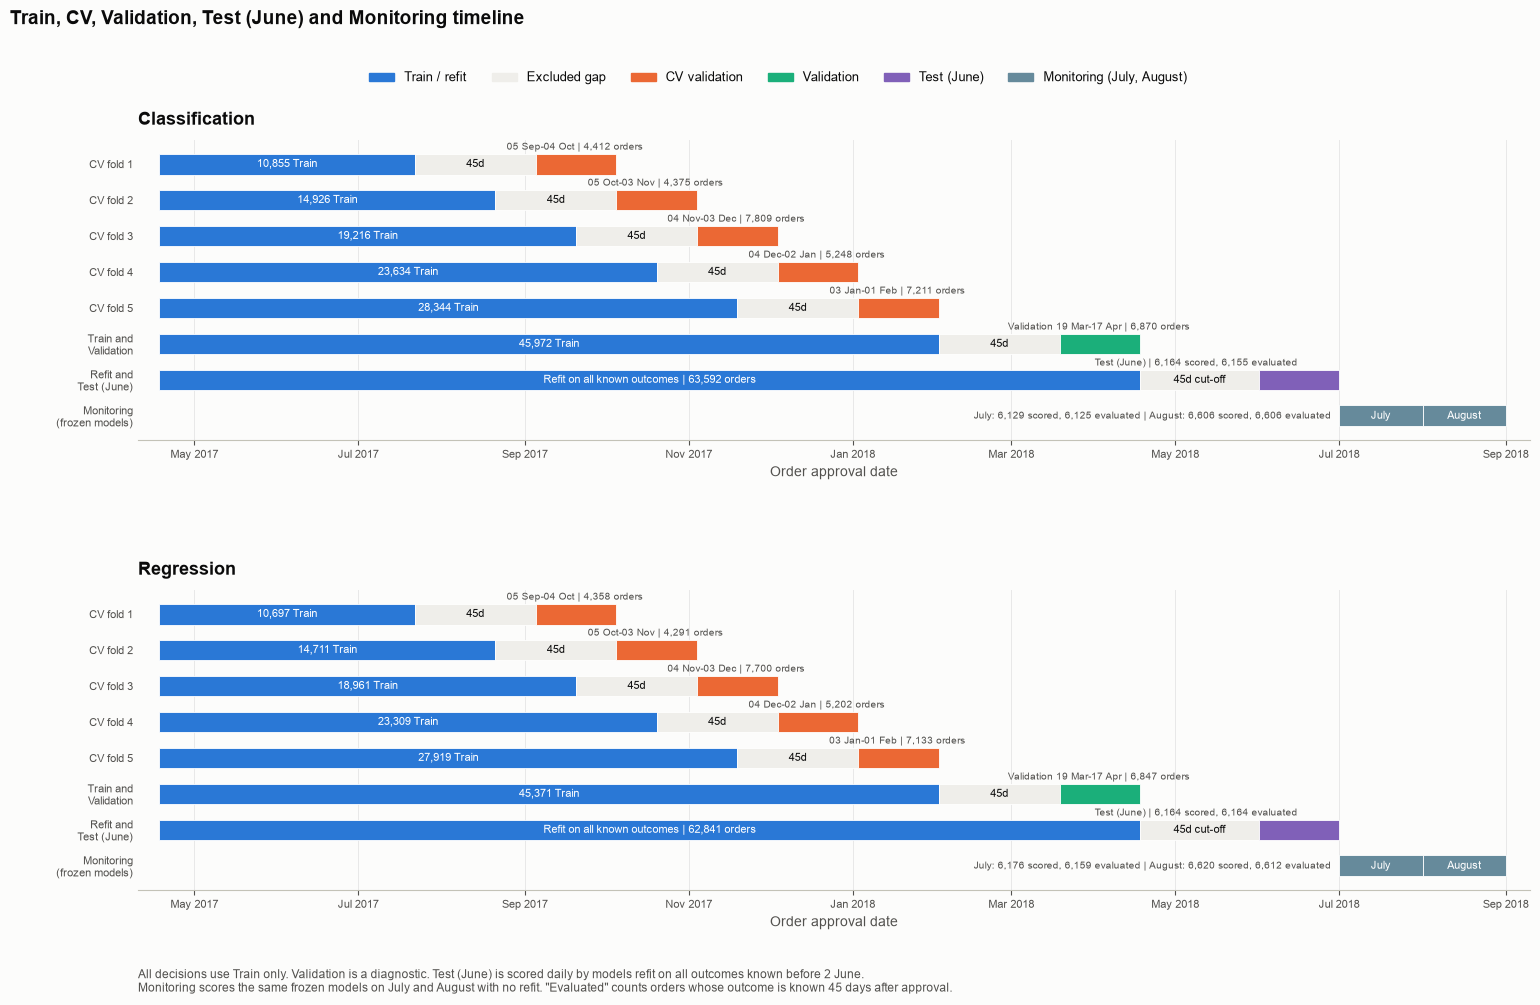

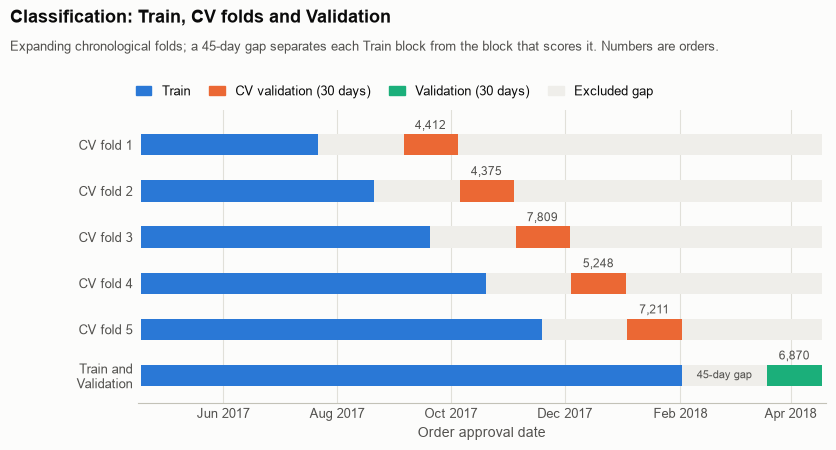

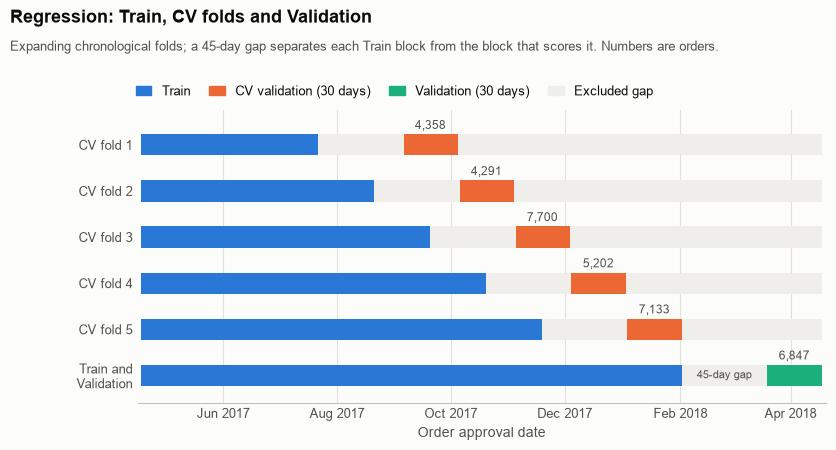

In [31]:
for task, td in task_data.items():
    figs.plot_split_and_folds(td.train_df['order_approved_dt'], td.validation_df['order_approved_dt'],
                              td.folds, task_label=task.capitalize(),
                              save_path=FIGURE_DIR / f'01_cv_folds_{task}.png')

In [32]:
def fold_table(td):
    dates = td.train_df['order_approved_dt'].dt.normalize()
    return pd.DataFrame([{'task': td.task, 'fold': k, 'train_orders': len(tr), 'cv_orders': len(va),
                          'cv_start': dates.iloc[va].min().date(), 'cv_end': dates.iloc[va].max().date()}
                         for k, (tr, va) in enumerate(td.folds, 1)])

fold_summary = pd.concat([fold_table(td) for td in task_data.values()], ignore_index=True)
fold_summary.to_csv(DATA_DIR / '01_cv_folds.csv', index=False)
fold_summary

,task,fold,train_orders,cv_orders,cv_start,cv_end
0,classification,1,10855,4412,2017-09-05,2017-10-04
1,classification,2,14926,4375,2017-10-05,2017-11-03
2,classification,3,19216,7809,2017-11-04,2017-12-03
3,classification,4,23634,5248,2017-12-04,2018-01-02
4,classification,5,28344,7211,2018-01-03,2018-02-01
5,regression,1,10697,4358,2017-09-05,2017-10-04
6,regression,2,14711,4291,2017-10-05,2017-11-03
7,regression,3,18961,7700,2017-11-04,2017-12-03
8,regression,4,23309,5202,2017-12-04,2018-01-02
9,regression,5,27919,7133,2018-01-03,2018-02-01


**Outputs.** Figures: `01_label_buffer_audit`, `01_waiting_period_audit`, `01_skewness_before_after`, `01_cyclic_calendar`, `01_validation_timeline`, `01_cv_folds_classification` and `01_cv_folds_regression` in `results/simple_to_complex/figures/`. Tables: the `01_*.csv` files and `linear_design_vif.csv` in `results/simple_to_complex/data/`; the multicollinearity audit in `results/feature_selection/`.